In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
device.type

'cuda'

In [ ]:
# PREPROCESIRANJE KOJE TREBA DA BUDE UNUTAR TRENINGA - ne koristi se
# NE POKRECI
import cv2
# Example normalization
def preprocess(image):
    # Resize to 227x227
    resized_image = cv2.resize(image, (227, 227))
    
    # Normalize pixel values
    normalized_image = resized_image / 255.0
    
    return normalized_image


In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset

class QuickDraw0Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}  # novo: mapiranje indeks → naziv
        self.classes = []       # novo: lista imena klasa

        # Pronađi sve klase (nazive foldera)
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                self.classes.append(class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(class_path, fname), class_name))  # ovde dodaješ naziv klase

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, class_name  # vraćamo naziv klase kao label
    '''
    
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[class_name]  # vrati int umesto string
        return image, label

In [4]:
import torchvision.transforms as transforms
direc = "balanced_chosen_3_images"
transform = transforms.Compose([
    transforms.Resize((227, 227)),  # ekvivalent cv2.resize
    transforms.ToTensor(),          # automatski skalira u [0, 1]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],       # opcionalna normalizacija (centar na 0)
        std=[0.5, 0.5, 0.5]
    )
])

dataset = QuickDraw0Dataset(direc, transform=transform)

In [ ]:
# MOZDA BUDE POTREBNO, TRENUTNO NE SLUZI NICEMU
# NE POKRECI
from torch.utils.data import Subset


def create_subset(dataset, fraction=0.25):
    total_size = len(dataset)
    subset_size = int(total_size * fraction)
    
    indices = list(range(total_size))
    subset_indices = indices[:subset_size]
    
    return Subset(dataset, subset_indices)


subset_dataset = create_subset(dataset, fraction=0.25)

In [5]:
from torch.utils.data import Dataset, DataLoader, random_split

# Podeli dataset na trening (70%), validacioni (15%) i test set (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [6]:
# Kreiraj DataLoader-e
batchsize = 64
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

In [7]:
class AlexNet(nn.Module):
        def __init__(self, num_classes):
            super(AlexNet, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
                nn.BatchNorm2d(96),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer3 = nn.Sequential(
                nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer4 = nn.Sequential(
                nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer5 = nn.Sequential(
                nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(9216, 4096),
                nn.ReLU())
            self.fc1 = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(4096, 4096),
                nn.ReLU())
            self.fc2= nn.Sequential(
                nn.Linear(4096, num_classes))

        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.layer4(out)
            out = self.layer5(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.fc1(out)
            out = self.fc2(out)
            return out

In [8]:
alexnet = AlexNet(3)

In [8]:
from torchsummary import summary
# Instantiate model
alexnet = AlexNet(3)
# Get complete summary of AlexNet
summary(alexnet, (3, 227, 227), batch_size=128)

ModuleNotFoundError: No module named 'torchsummary'

In [9]:
print(device)

cuda


In [10]:
alexnet = alexnet.to(device)

In [11]:
import torch.optim as optim
train_loss = []
train_accuracy = []
val_losslist = []
val_accuracy = []

#os.makedirs("saved_models_top3_vgg_0", exist_ok=True)
#alexnet.load_state_dict(torch.load("saved_models/alexnet/model_epoch_9.pth"))
#alexnet.to(device)
start = 0
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(alexnet.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(start, 10):  # Run for 10 epochs
    alexnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        train_accuracy.append(100 * correct / total)
        train_loss.append(running_loss/len(train_loader))
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
      
    model_path = f"saved_models/alexnet3.2/model_epoch_{epoch+1}.pth"
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    torch.save(alexnet.state_dict(), model_path)

    alexnet.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = alexnet(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    val_accuracy.append(100 * correct / total)
    val_losslist.append(val_loss/len(val_loader))

    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 0.8072, Accuracy: 65.19%
Validation Loss: 0.6749678701162338, Accuracy: 66.49%
Epoch [2/10], Loss: 0.3544, Accuracy: 87.62%
Validation Loss: 0.19744016928598285, Accuracy: 87.12%
Epoch [3/10], Loss: 0.2147, Accuracy: 93.14%
Validation Loss: 0.14206524207111215, Accuracy: 93.32%
Epoch [4/10], Loss: 0.1531, Accuracy: 94.95%
Validation Loss: 0.1290570744749857, Accuracy: 94.83%
Epoch [5/10], Loss: 0.1231, Accuracy: 96.19%
Validation Loss: 0.1286013807339259, Accuracy: 96.50%
Epoch [6/10], Loss: 0.1013, Accuracy: 96.71%
Validation Loss: 0.1251067716216312, Accuracy: 97.26%
Epoch [7/10], Loss: 0.0875, Accuracy: 97.19%
Validation Loss: 0.11970834824001031, Accuracy: 97.02%
Epoch [8/10], Loss: 0.0696, Accuracy: 97.67%
Validation Loss: 0.12758281911010272, Accuracy: 97.73%
Epoch [9/10], Loss: 0.0540, Accuracy: 98.43%
Validation Loss: 0.12532474005740823, Accuracy: 98.05%
Epoch [10/10], Loss: 0.0463, Accuracy: 98.95%
Validation Loss: 0.11820267746139734, Accuracy: 99.13%


In [16]:
print(train_loss)
print(train_accuracy)
print(val_losslist)
print(val_accuracy)

[0.019533505945494682, 0.03090193596753207, 0.04473901156223181, 0.06199495539520726, 0.07396374868624138, 0.08662453203490286, 0.1035791328459075, 0.11957638372074474, 0.13089089592297873, 0.14436608643242807, 0.15799643776633523, 0.17011820095958133, 0.18276426376718463, 0.19700284347389685, 0.20691991303906296, 0.21734435630567145, 0.2347344160079956, 0.24784304607998242, 0.2595703439279036, 0.27083621874000086, 0.28619212363705493, 0.2977511765378894, 0.30567151398369763, 0.3135175650770014, 0.32510375705632294, 0.3348843346942555, 0.3433364449125348, 0.3506991474917441, 0.3585072701627558, 0.3681072773355426, 0.3758460030411229, 0.3845706175674092, 0.39335402394786023, 0.01127114621075717, 0.017097435665853096, 0.02822797181028308, 0.03461199908545523, 0.04227975191492023, 0.04937371476130052, 0.055454854712341774, 0.06574359355550824, 0.07022726580952153, 0.07831938384157239, 0.08342549069361253, 0.09235647275592342, 0.0990661418799198, 0.10550541137204025, 0.1155459104162274, 0.

In [17]:
train_loss = [0.3934, 0.2248, 0.1521, 0.1246, 0.1009, 0.0811, 0.0612, 0.0536, 0.0404, 0.0360]
train_accuracy = [87.81, 92.62, 94.52, 96.00, 96.71, 97.76, 98.14, 98.14, 99.05, 99.14]

val_losslist = [0.1894, 0.1623, 0.1240, 0.1050, 0.1521, 0.0980, 0.1385, 0.1938, 0.1168, 0.1347]
val_accuracy = [88.87, 92.89, 95.11, 96.34, 96.62, 96.86, 98.13, 98.45, 98.89, 98.97]


In [ ]:
import torch
from torchvision import models
from sklearn.metrics import classification_report
from tqdm import tqdm  # za lepši prikaz progres bara (opciono)

# Učitaj težine
alexnet.load_state_dict(torch.load('saved_models/alexnet3.2/model_epoch_10.pth', map_location=device))
alexnet = alexnet.to(device)
alexnet.eval()

# 2. Evaluacija
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Izračunaj metrike
print("=== Izveštaj klasifikacije ===")
print(classification_report(y_true, y_pred, digits=4))

100%|██████████| 8/8 [00:01<00:00,  4.38it/s]

=== Izveštaj klasifikacije ===
              precision    recall  f1-score   support

           0     0.9926    0.9310    0.9609       145
           1     0.9781    0.9116    0.9437       147
           2     0.8757    0.9810    0.9254       158

    accuracy                         0.9422       450
   macro avg     0.9488    0.9412    0.9433       450
weighted avg     0.9468    0.9422    0.9428       450



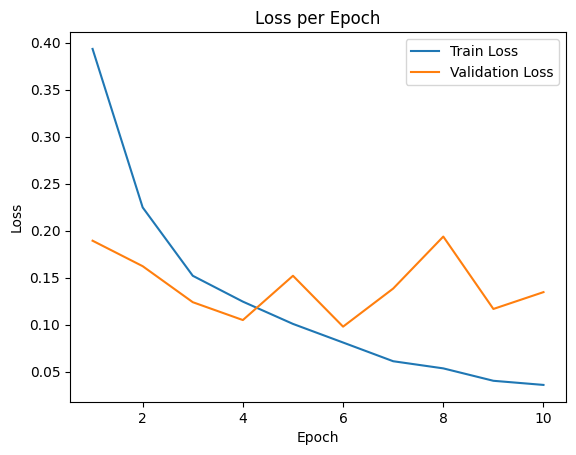

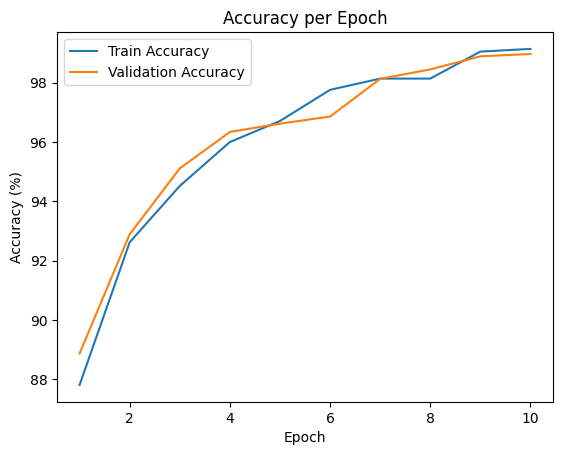

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_losslist, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()

plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")
plt.show()